# Plotting with pandas and seaborn

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# pandas plotting is built on matplotlib
# But provides easier syntax for DataFrames

### Advantages of Plotting with Pandas
|Advantage|	Description|
|---------|------------|
Simpler syntax	|No need to extract columns manually; you can call `.plot()` directly on DataFrame/Series
Automatic indexing|	Uses DataFrame index as the x-axis automatically
Seamless integration	|Works natively with pandas data structures (DataFrame, Series)
Better default styles|	Produces more visually appealing plots compared to raw matplotlib

### Additional Benefits:
- Quick exploration – Ideal for fast data visualization during EDA
- Built-in grouping – Supports `by` parameter for grouping data
- Subplots support – Easy to create multiple subplots with `subplots=True`
- Handles datetime – Automatically formats datetime indexes

## Line Plots

<Axes: >

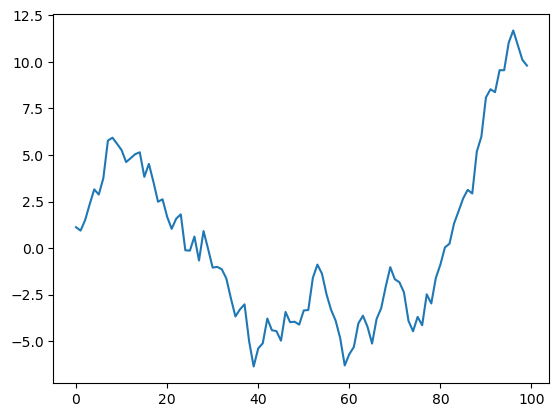

In [ ]:
# Create sample data With Series
s = pd.Series(np.random.randn(100).cumsum(), index=np.arange(100))

# Simple Line Plot
s.plot()

### Line plot customization

<Axes: title={'center': 'Random Walk Data'}, xlabel='Index', ylabel='Value'>

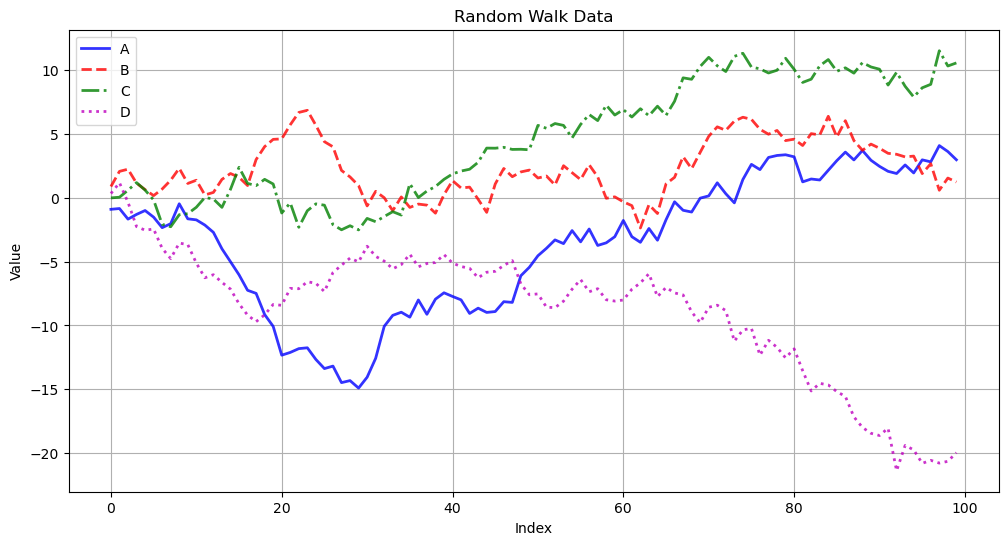

In [11]:
# Create sample data with DataFrame
df = pd.DataFrame(np.random.randn(100, 4).cumsum(0),
                  columns=['A', 'B', 'C', 'D'],
                  index=np.arange(100))

# Customize line plot
df.plot(
    figsize=(12, 6),                    # Figure size
    title='Random Walk Data',           # Title
    grid=True,                          # Show grid
    style=['b-', 'r--', 'g-.', 'm:'],   # Line styles
    linewidth=2,                        # Line width
    alpha=0.8,                          # Transparency
    legend=True,                        # Show legend
    xlabel='Index',                     # X label
    ylabel='Value'                      # Y label
    )

### Line plot with dates (time series)

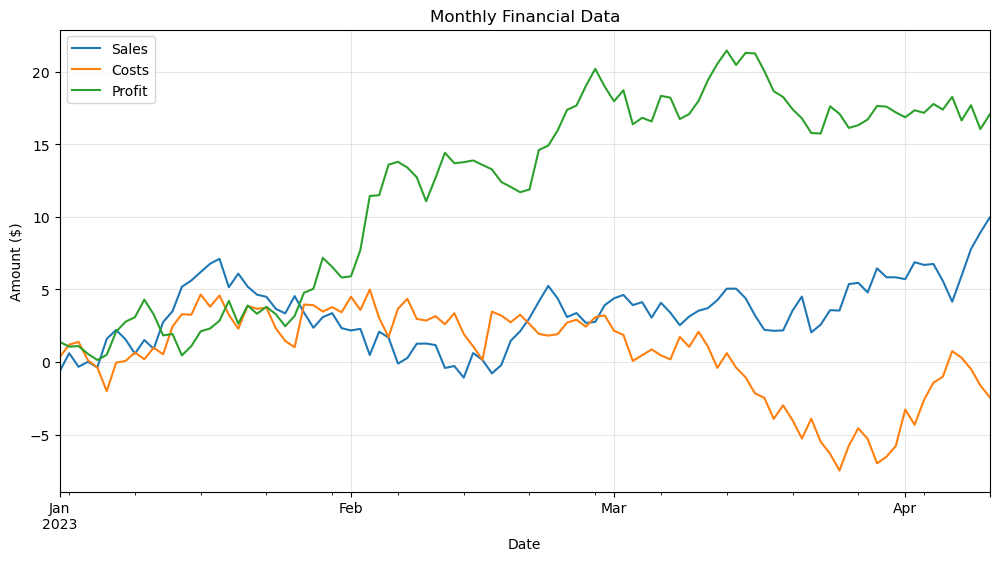

In [13]:
# Create time series data
dates = pd.date_range('2023-01-01', periods=100, freq='D')
df_ts = pd.DataFrame(
    np.random.randn(100, 3).cumsum(0),
    index=dates,
    columns=['Sales', 'Costs', 'Profit']
)

# Plot with datetime index
df_ts.plot(figsize=(12, 6), title='Monthly Financial Data')
plt.xlabel('Date')
plt.ylabel('Amount ($)')
plt.legend(loc='best')
plt.grid(True, alpha=0.3)
plt.show()

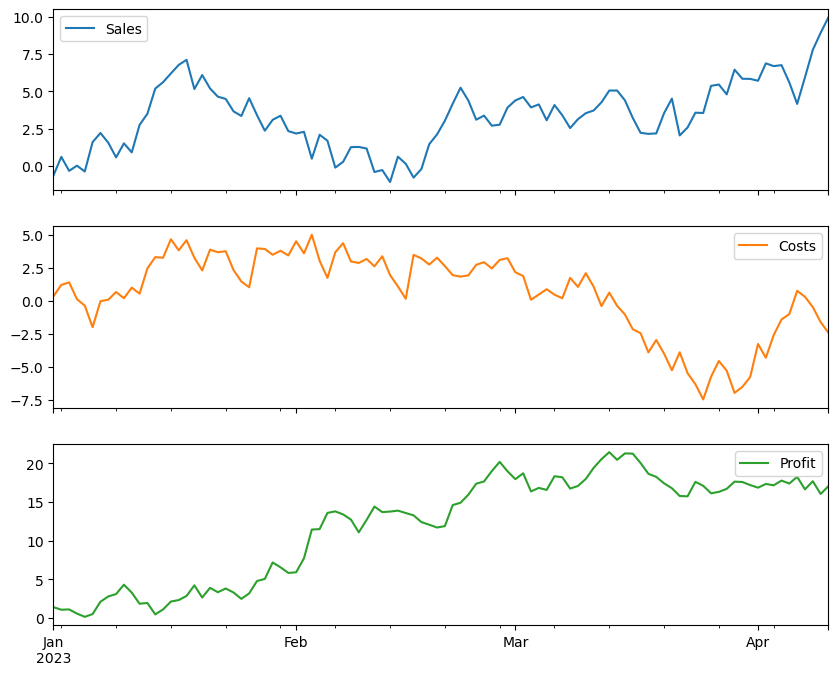

In [14]:
# Subplots for each column
df_ts.plot(subplots=True, figsize=(10, 8), layout=(3, 1))
plt.show()

## Bar Plot

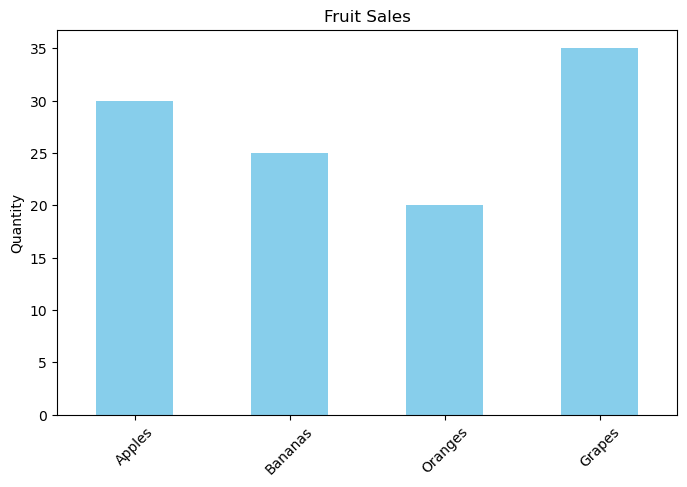

In [16]:
# From the book example
# Create sample categorical data
data = {'Apples': 30, 'Bananas': 25, 'Oranges': 20, 'Grapes': 35}
s = pd.Series(data)

# Vertical bar plot
s.plot(kind='bar', figsize=(8, 5), color='skyblue')
plt.title('Fruit Sales')
plt.ylabel('Quantity')
plt.xticks(rotation=45)  # Rotate x labels
plt.show()

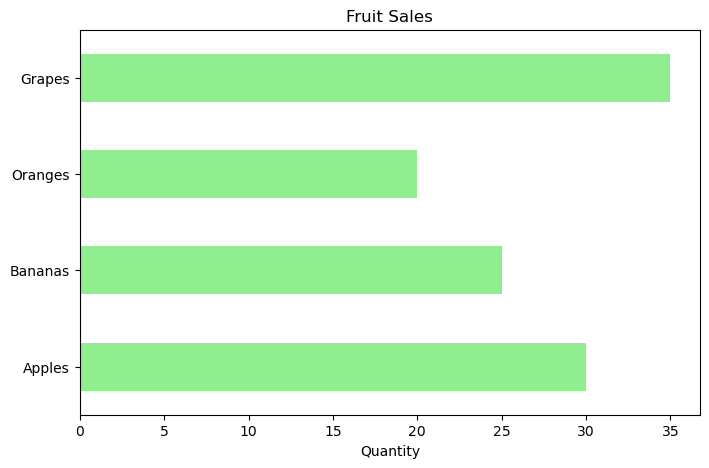

In [ ]:
# Horizontal bar plot
s.plot(kind='barh', figsize=(8, 5), color='lightgreen')
plt.title('Fruit Sales')
plt.xlabel('Quantity')
plt.show()

### Grouped bar chart

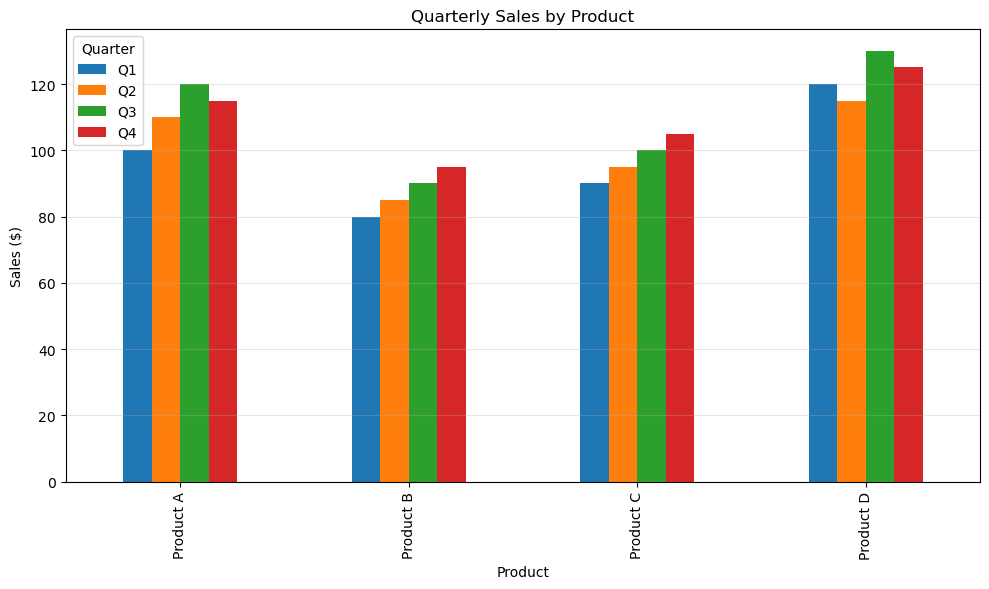

In [19]:
# DataFrame with multiple categories
df_bar = pd.DataFrame({
    'Q1': [100, 80, 90, 120],
    'Q2': [110, 85, 95, 115],
    'Q3': [120, 90, 100, 130],
    'Q4': [115, 95, 105, 125]
}, index=['Product A', 'Product B', 'Product C', 'Product D'])

# Grouped bar plot
df_bar.plot(kind='bar', figsize=(10, 6))
plt.title('Quarterly Sales by Product')
plt.ylabel('Sales ($)')
plt.xlabel('Product')
plt.legend(title='Quarter')
plt.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

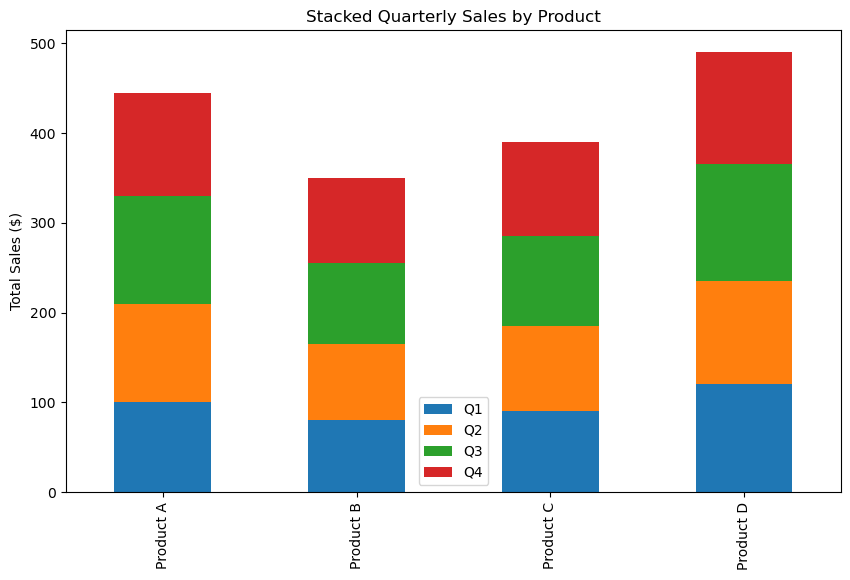

In [20]:
# Stacked bar plot
df_bar.plot(kind='bar', stacked=True, figsize=(10, 6))
plt.title('Stacked Quarterly Sales by Product')
plt.ylabel('Total Sales ($)')
plt.show()

### Different columns with different colors

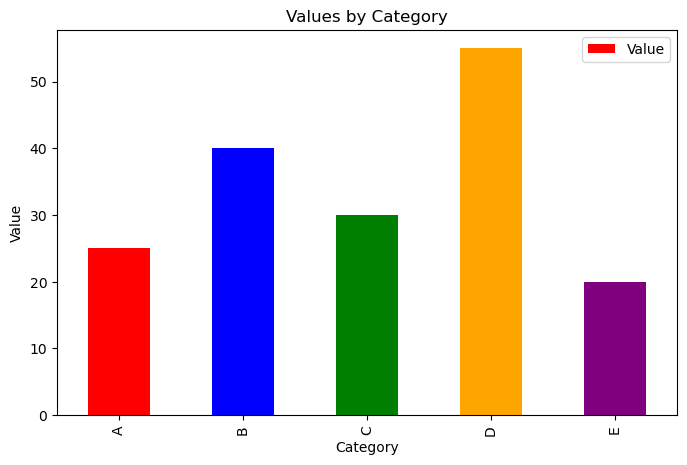

In [21]:
# From the book example
data = {'Category': ['A', 'B', 'C', 'D', 'E'],
        'Value': [25, 40, 30, 55, 20]}
df = pd.DataFrame(data)

# Custom colors
colors = ['red', 'blue', 'green', 'orange', 'purple']
df.plot(kind='bar', x='Category', y='Value', 
        color=colors, figsize=(8, 5))
plt.title('Values by Category')
plt.ylabel('Value')
plt.show()

## Histograms and Density Plots

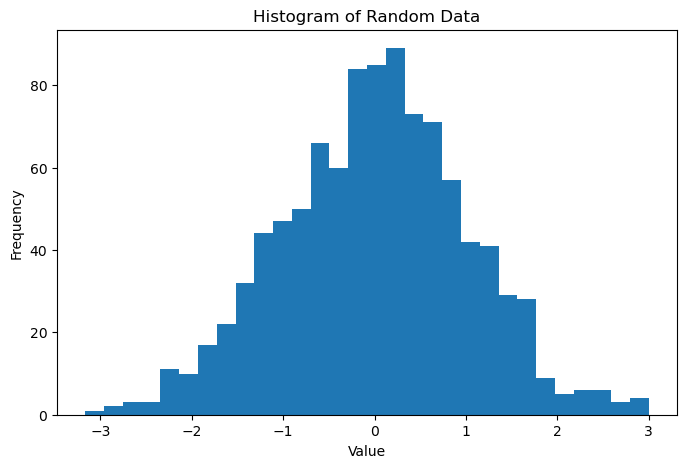

In [23]:
# From the book example
# Create random data
data = np.random.randn(1000)
s = pd.Series(data)

# Basic histogram
s.plot(kind='hist', bins=30, figsize=(8, 5))
plt.title('Histogram of Random Data')
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.show()

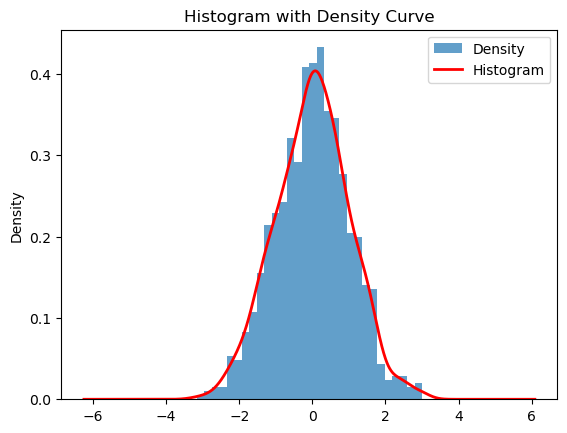

In [24]:
# Histogram with density curve
s.plot(kind='hist', bins=30, density=True, alpha=0.7)
s.plot(kind='kde', color='red', linewidth=2)  # Add density curve
plt.title('Histogram with Density Curve')
plt.legend(['Density', 'Histogram'])
plt.show()

### Histogram of multiple columns

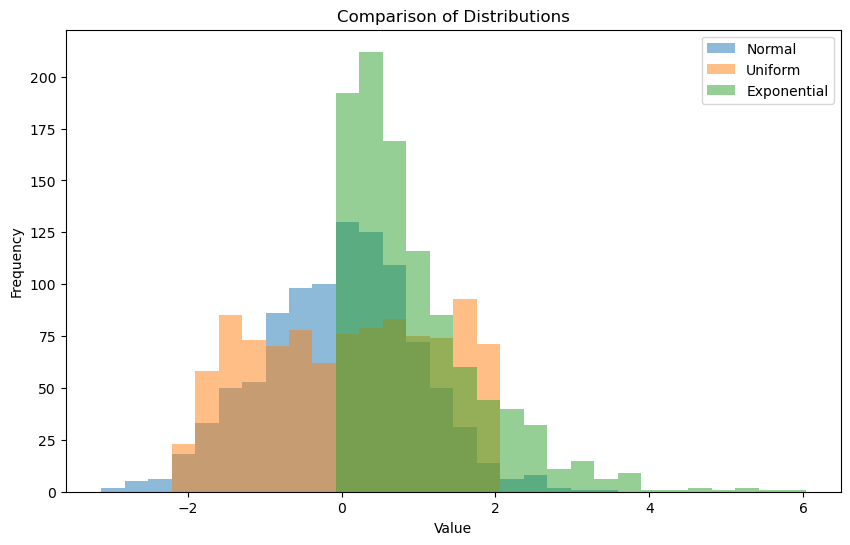

In [27]:
# Compare distributions
df_hist = pd.DataFrame({
    'Normal': np.random.randn(1000),
    'Uniform': np.random.rand(1000) * 4 - 2,
    'Exponential': np.random.exponential(1, 1000)
})

# Overlay histograms
df_hist.plot(kind='hist', bins=30, alpha=0.5, figsize=(10, 6))
plt.title('Comparison of Distributions')
plt.xlabel('Value')
plt.show()

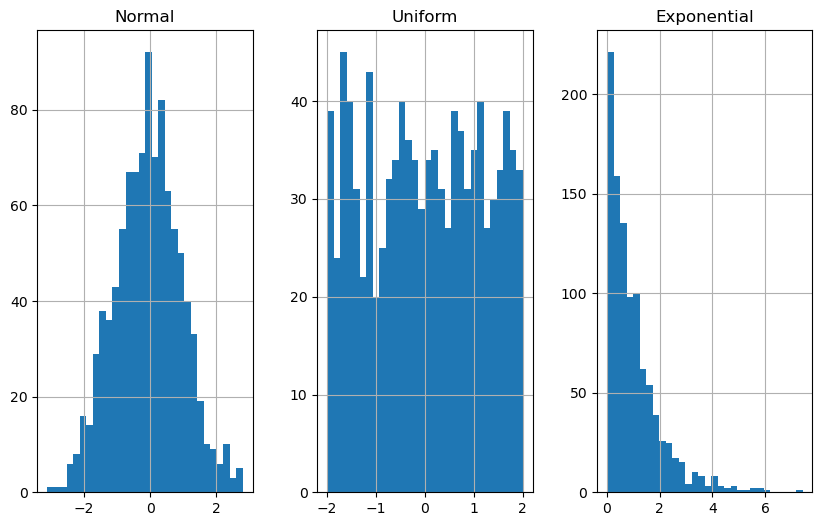

In [26]:
# Separate histograms in subplots
df_hist.hist(bins=30, figsize=(10, 6), layout=(1, 3))
plt.show()

### Density Plots (KDE)

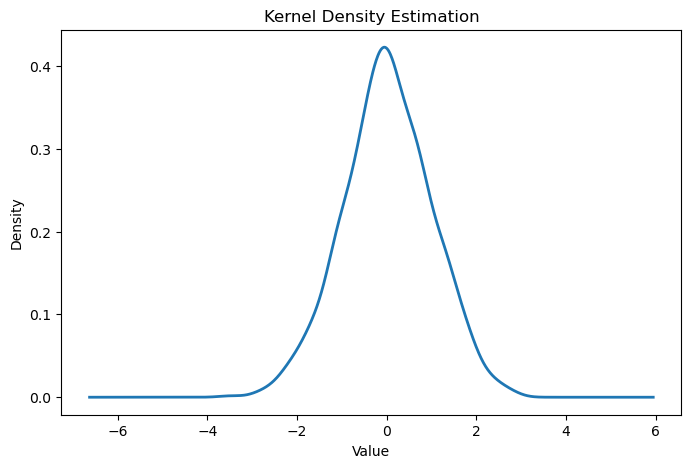

In [30]:
# From the book example
s = pd.Series(np.random.randn(1000))

# KDE plot
s.plot(kind='kde', figsize=(8, 5), linewidth=2)
plt.title('Kernel Density Estimation')
plt.xlabel('Value')
plt.show()

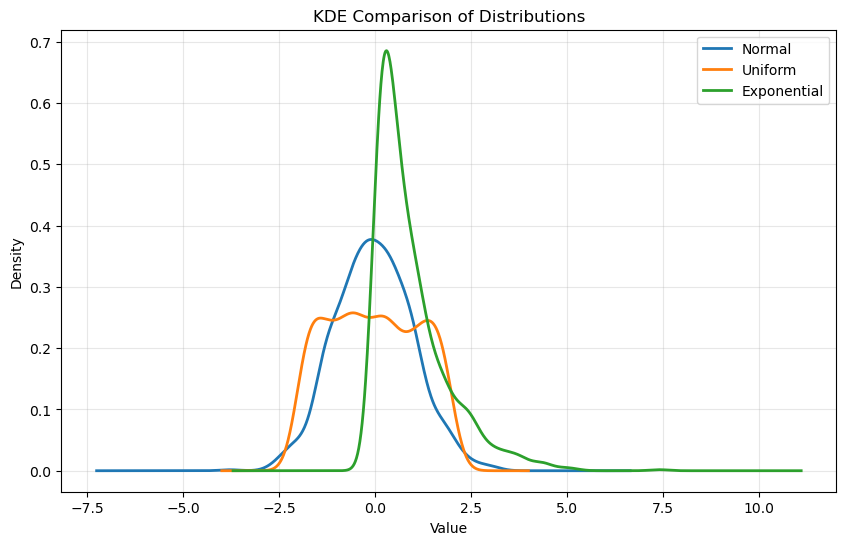

In [29]:
# Multiple KDE plots
df_kde = pd.DataFrame({
    'Normal': np.random.randn(1000),
    'Uniform': np.random.rand(1000) * 4 - 2,
    'Exponential': np.random.exponential(1, 1000)
})

df_kde.plot(kind='kde', figsize=(10, 6), linewidth=2)
plt.title('KDE Comparison of Distributions')
plt.xlabel('Value')
plt.grid(True, alpha=0.3)
plt.show()

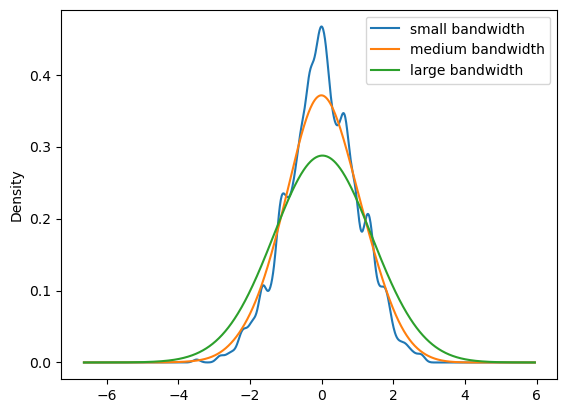

In [31]:
# KDE with bandwidth control
s.plot(kind='kde', bw_method=0.1, label='small bandwidth')
s.plot(kind='kde', bw_method=0.5, label='medium bandwidth')
s.plot(kind='kde', bw_method=1.0, label='large bandwidth')
plt.legend()
plt.show()

## Scatter or Point Plots

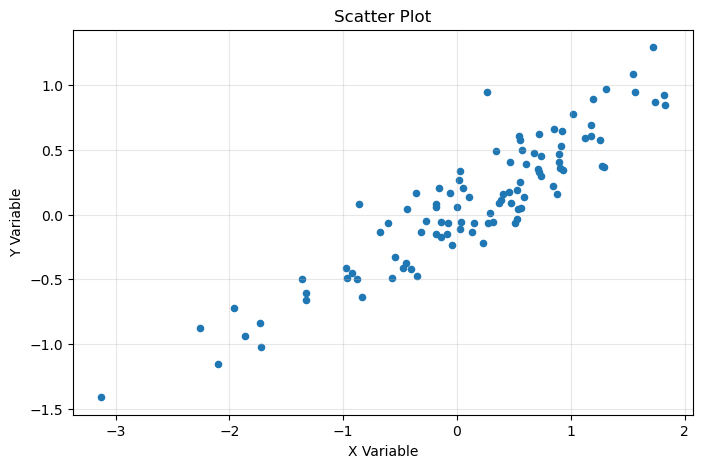

In [34]:
# From the book example
# Create correlated data
n = 100
x = np.random.randn(n)
y = 0.5 * x + 0.2 * np.random.randn(n)

df_scatter = pd.DataFrame({'X': x, 'Y': y})

# Basic scatter plot
df_scatter.plot(kind='scatter', x='X', y='Y', figsize=(8, 5))
plt.title('Scatter Plot')
plt.xlabel('X Variable')
plt.ylabel('Y Variable')
plt.grid(True, alpha=0.3)
plt.show()

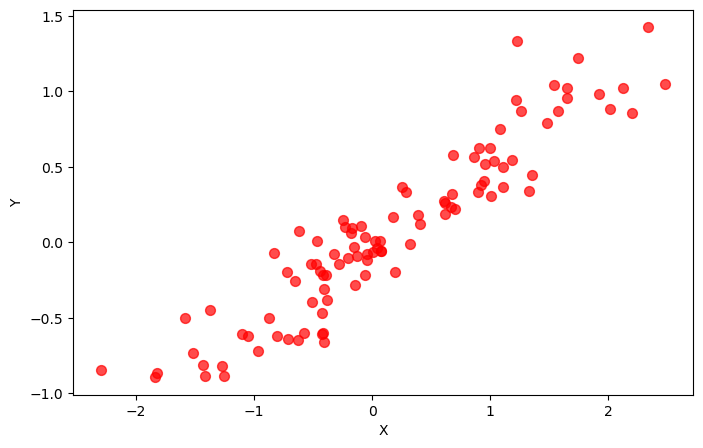

In [33]:
# Customize points
df_scatter.plot(kind='scatter', x='X', y='Y',
                figsize=(8, 5), 
                marker='o',        # Circle markers
                s=50,              # Marker size
                alpha=0.7,         # Transparency
                color='red')       # Color
plt.show()

### Scatter plot with colors based on categories

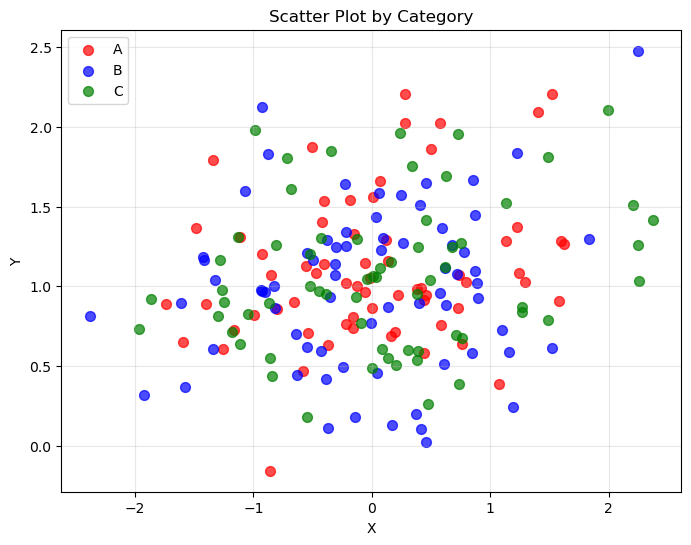

In [35]:
# Categorical scatter plot
categories = ['A', 'B', 'C']
n = 200
df_cat = pd.DataFrame({
    'X': np.random.randn(n),
    'Y': np.random.randn(n) * 0.5 + 1,
    'Category': np.random.choice(categories, n)
})

# Colors by category
colors = {'A': 'red', 'B': 'blue', 'C': 'green'}

# Using matplotlib directly for more control
fig, ax = plt.subplots(figsize=(8, 6))
for cat in categories:
    mask = df_cat['Category'] == cat
    ax.scatter(df_cat.loc[mask, 'X'], 
               df_cat.loc[mask, 'Y'],
               label=cat,
               color=colors[cat],
               alpha=0.7,
               s=50)
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_title('Scatter Plot by Category')
plt.show()

### scatter matrix (pairs plot)

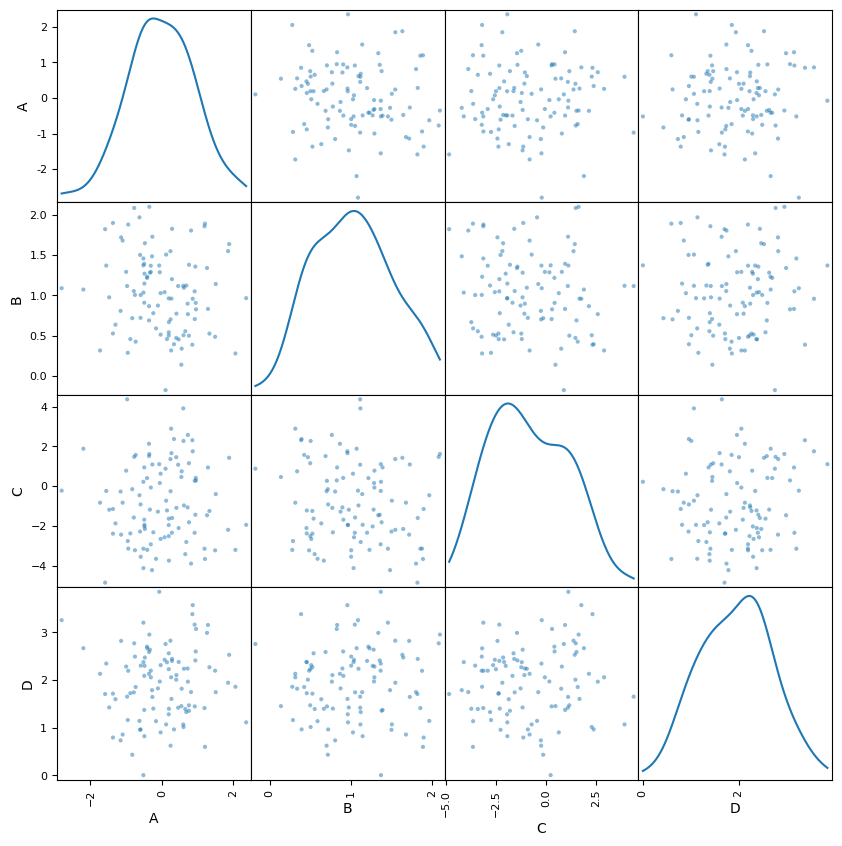

In [37]:
# From the book example
# Multiple variables
df_pairs = pd.DataFrame({
    'A': np.random.randn(100),
    'B': np.random.randn(100) * 0.5 + 1,
    'C': np.random.randn(100) * 2 - 1,
    'D': np.random.randn(100) * 0.8 + 2
})

# Scatter matrix using pandas
from pandas.plotting import scatter_matrix
scatter_matrix(df_pairs, alpha=0.5, figsize=(10, 10), diagonal='kde')
plt.show()

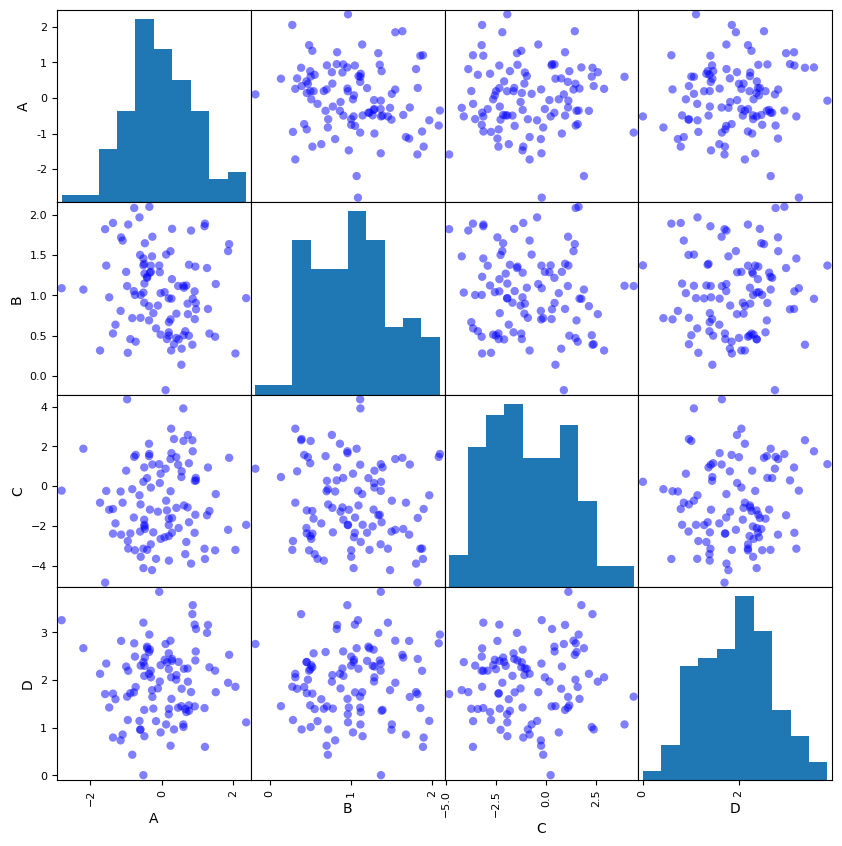

In [38]:
# Customize scatter matrix
scatter_matrix(df_pairs, 
               alpha=0.5, 
               figsize=(10, 10),
               diagonal='hist',      # Histogram on diagonal
               color='blue',          # Color of points
               marker='o')            # Marker style
plt.show()

## Facet Grids and Categorical Data

### Introduction to Seaborn for categorical plots

In [ ]:
import seaborn as sns

# Load example dataset
tips = sns.load_dataset('tips')
print(tips.head())

   total_bill   tip     sex smoker  day    time  size
0       16.99  1.01  Female     No  Sun  Dinner     2
1       10.34  1.66    Male     No  Sun  Dinner     3
2       21.01  3.50    Male     No  Sun  Dinner     3
3       23.68  3.31    Male     No  Sun  Dinner     2
4       24.59  3.61  Female     No  Sun  Dinner     4


### Box plot with Seaborn

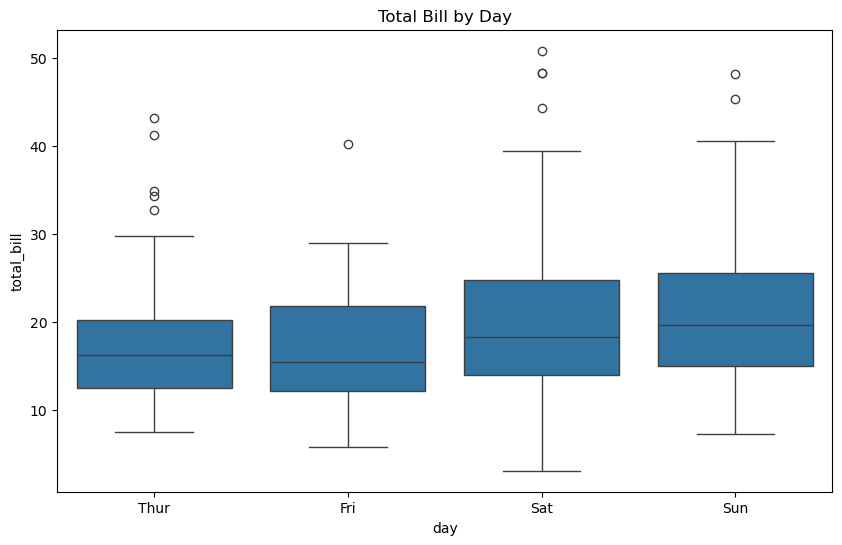

In [41]:
# Box plot by category
plt.figure(figsize=(10, 6))
sns.boxplot(x='day', y='total_bill', data=tips)
plt.title('Total Bill by Day')
plt.show()

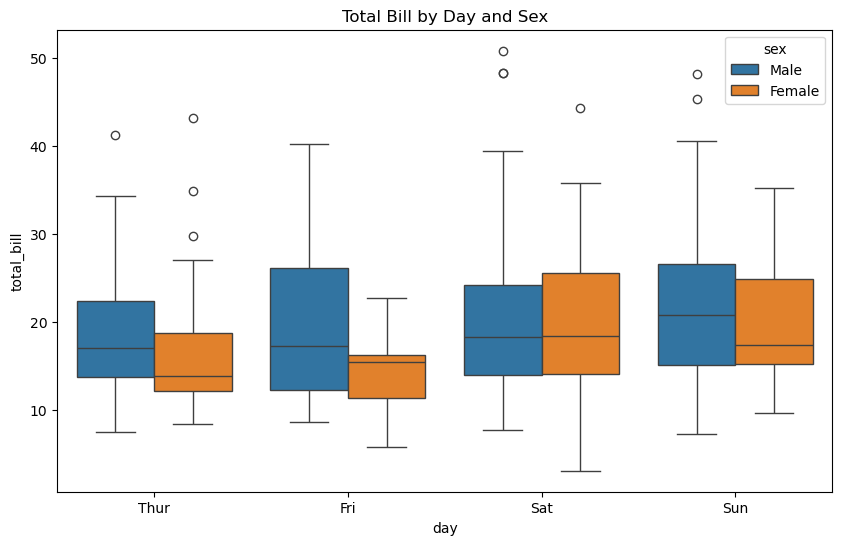

In [42]:
# Box plot with hue
plt.figure(figsize=(10, 6))
sns.boxplot(x='day', y='total_bill', hue='sex', data=tips)
plt.title('Total Bill by Day and Sex')
plt.show()

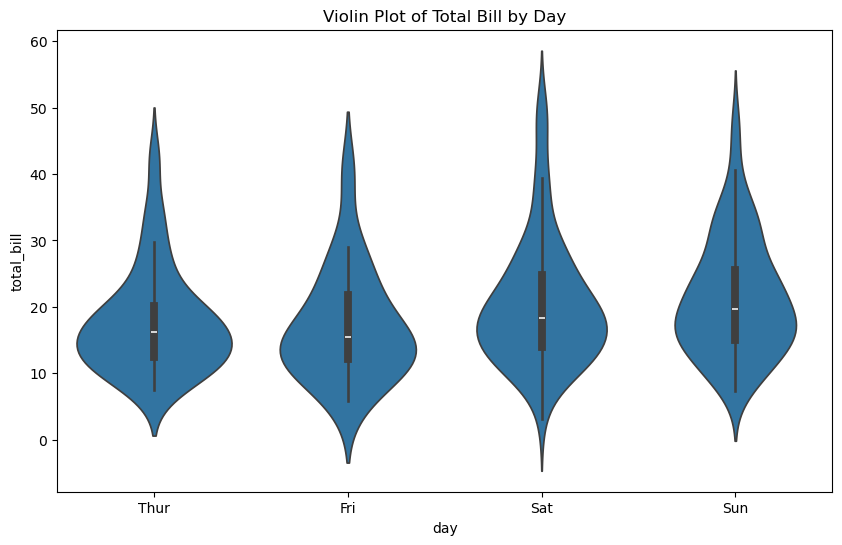

In [43]:
# Violin plot (like box plot with density)
plt.figure(figsize=(10, 6))
sns.violinplot(x='day', y='total_bill', data=tips)
plt.title('Violin Plot of Total Bill by Day')
plt.show()

### Bar plot with Seaborn

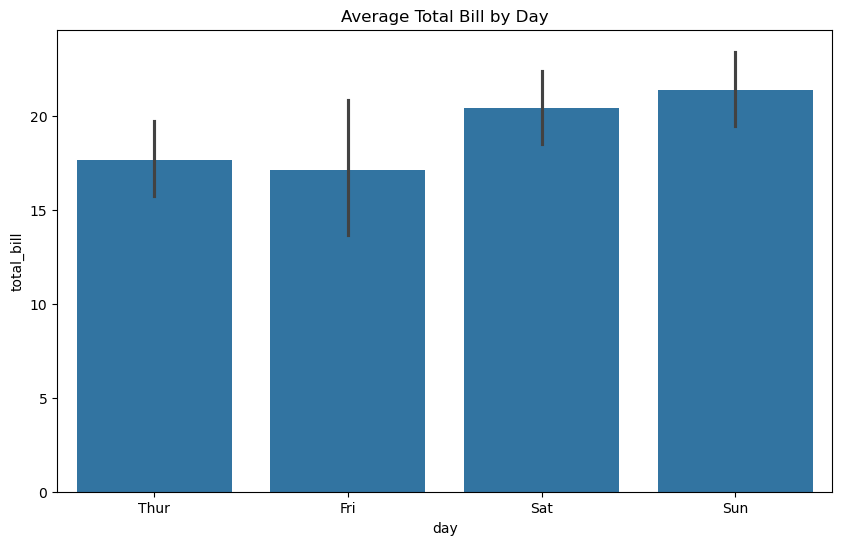

In [46]:
# Bar plot with error bars
plt.figure(figsize=(10, 6))
sns.barplot(x='day', y='total_bill', data=tips)
plt.title('Average Total Bill by Day')
plt.show()

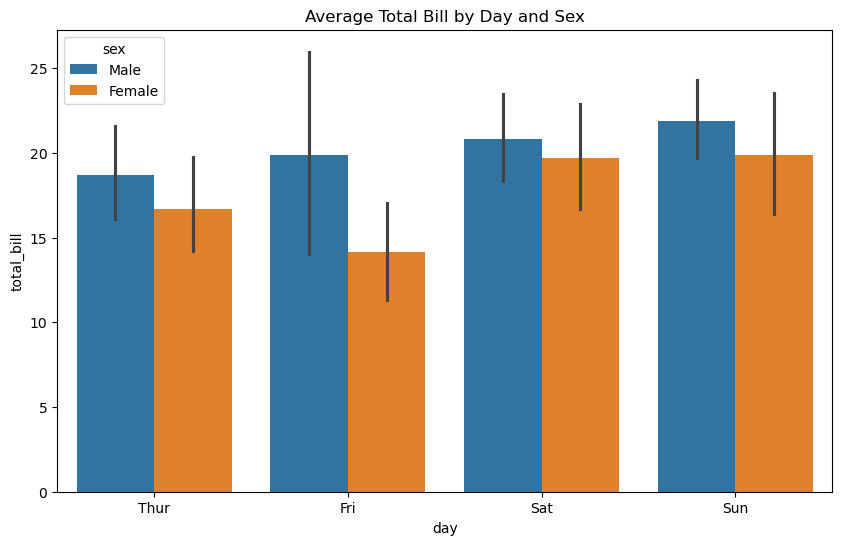

In [47]:
# Bar plot with hue
plt.figure(figsize=(10, 6))
sns.barplot(x='day', y='total_bill', hue='sex', data=tips)
plt.title('Average Total Bill by Day and Sex')
plt.show()

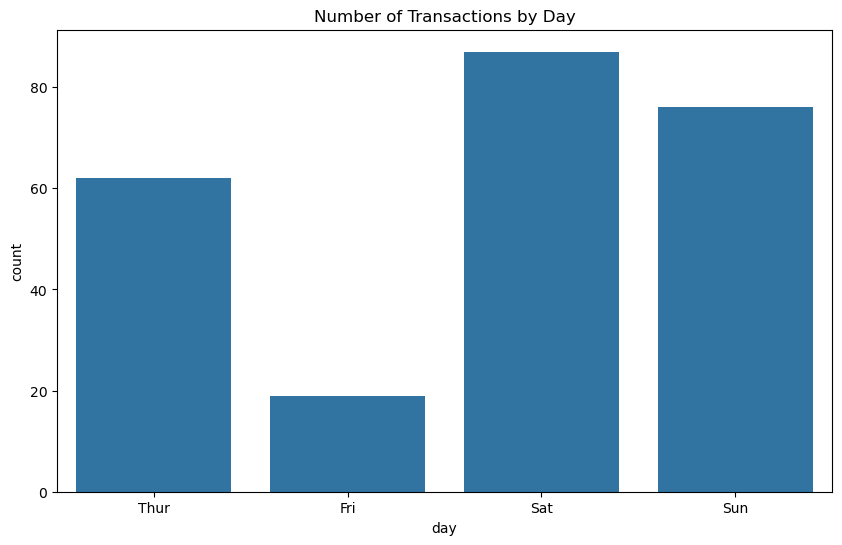

In [48]:
# Count plot (frequency of categories)
plt.figure(figsize=(10, 6))
sns.countplot(x='day', data=tips)
plt.title('Number of Transactions by Day')
plt.show()

### FacetGrid 

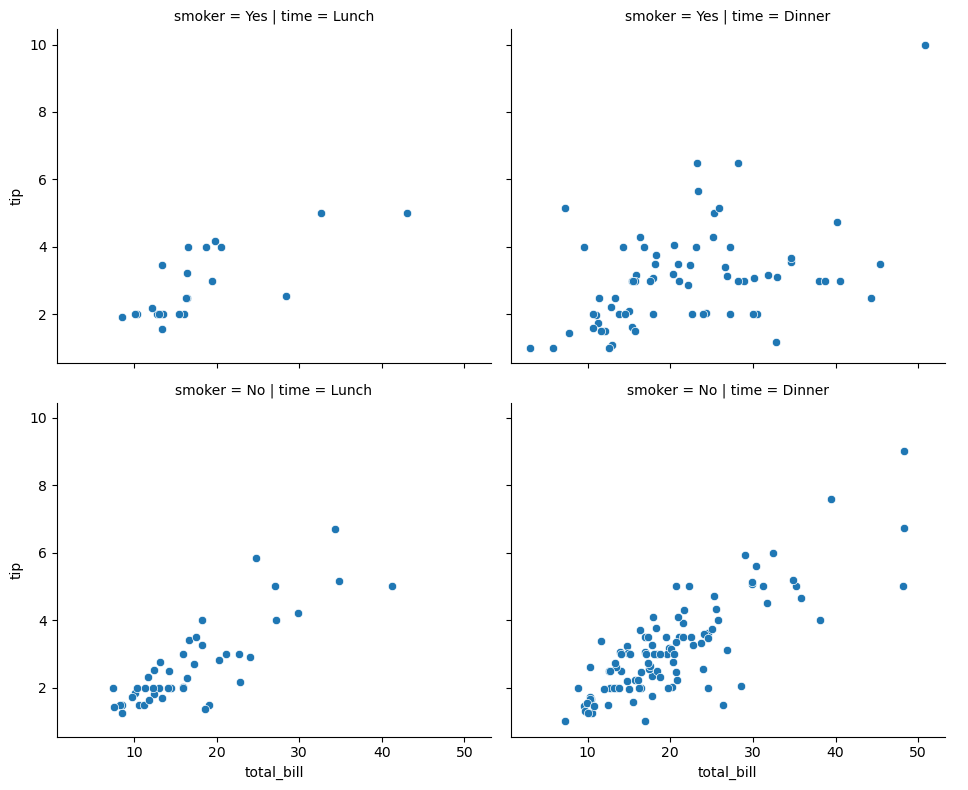

In [50]:
# Create a grid of plots by category
g = sns.FacetGrid(tips, col='time', row='smoker', height=4, aspect=1.2)
g.map(sns.scatterplot, 'total_bill', 'tip')
g.add_legend()
plt.show()

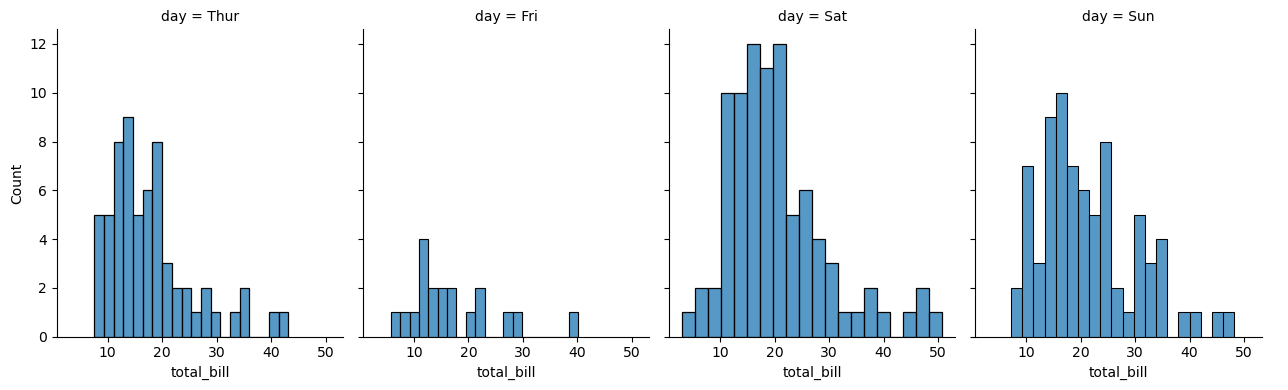

In [51]:
# Histograms in grid
g = sns.FacetGrid(tips, col='day', height=4, aspect=0.8)
g.map(sns.histplot, 'total_bill', bins=20)
g.add_legend()
plt.show()

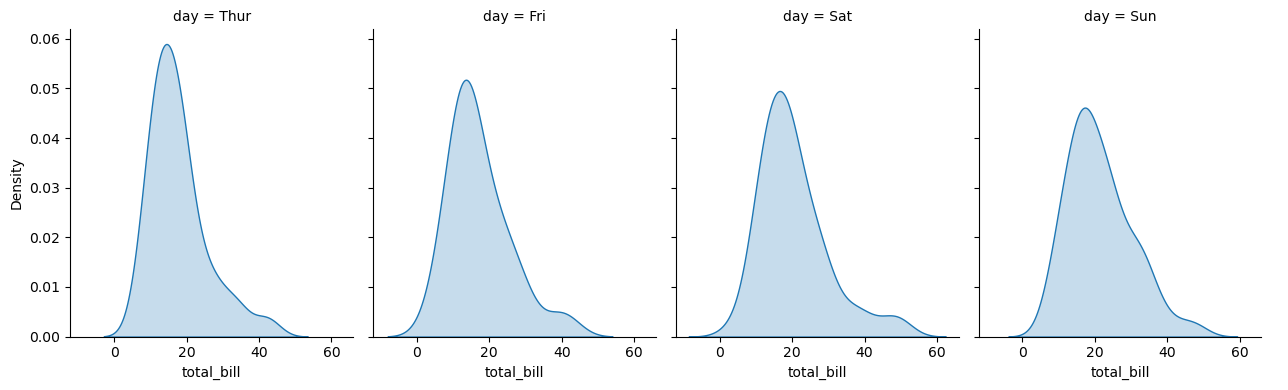

In [54]:
# KDE plots in grid
g = sns.FacetGrid(tips, col='day', height=4, aspect=0.8)
g.map(sns.kdeplot, 'total_bill', fill=True)  # shade=True → fill=True
g.add_legend()
plt.show()

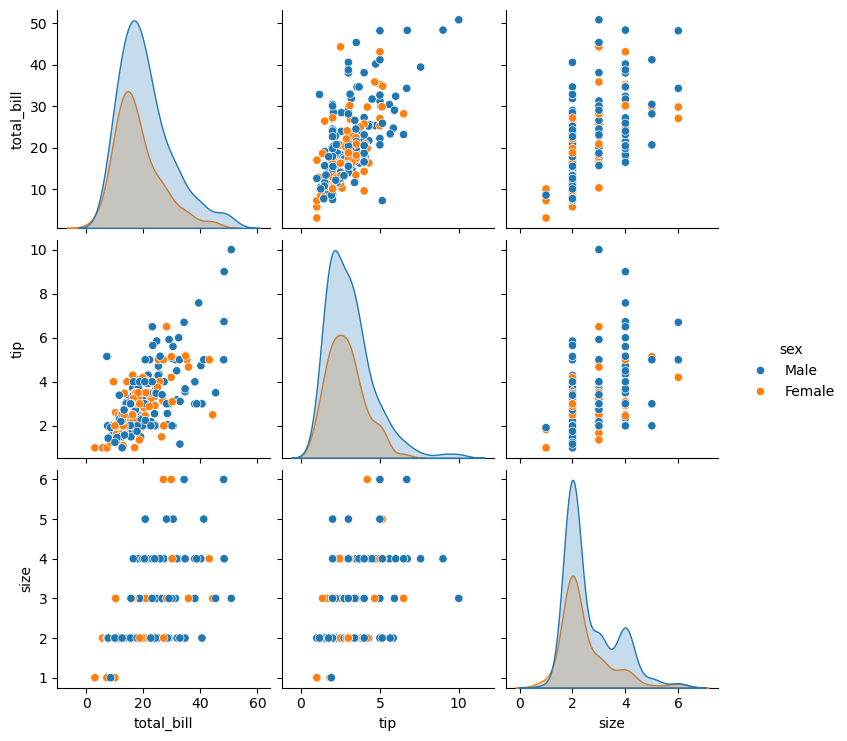

In [53]:
# Pair plot (like scatter matrix but with categories)
sns.pairplot(tips, hue='sex', diag_kind='kde')
plt.show()

## Seaborn Style Customization

In [58]:
# Available styles
print(sns.get_theme_names())  # ['dark', 'ticks', 'white', ...]

# Set style
sns.set_theme(style='whitegrid')
sns.set_palette('viridis')
sns.set_context('notebook')

# Different themes
themes = ['darkgrid', 'whitegrid', 'dark', 'white', 'ticks']
for theme in themes:
    plt.figure(figsize=(8, 4))
    sns.set_theme(style=theme)
    sns.lineplot(data=df.cumsum())
    plt.title(f'Theme: {theme}')
    plt.show()

# Reset
sns.set_theme()

AttributeError: module 'seaborn' has no attribute 'get_theme_names'

<Figure size 800x400 with 0 Axes>

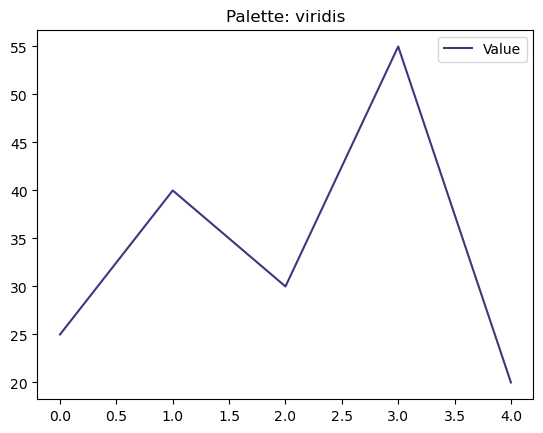

<Figure size 800x400 with 0 Axes>

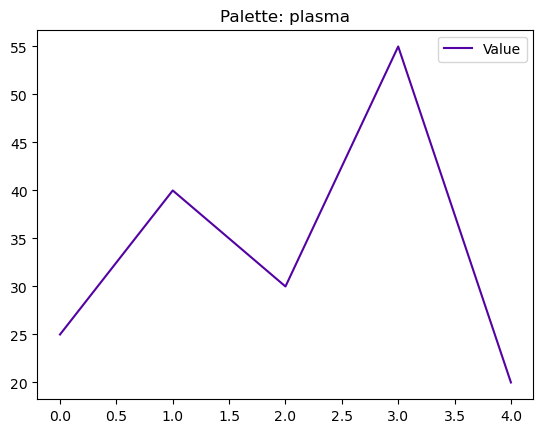

<Figure size 800x400 with 0 Axes>

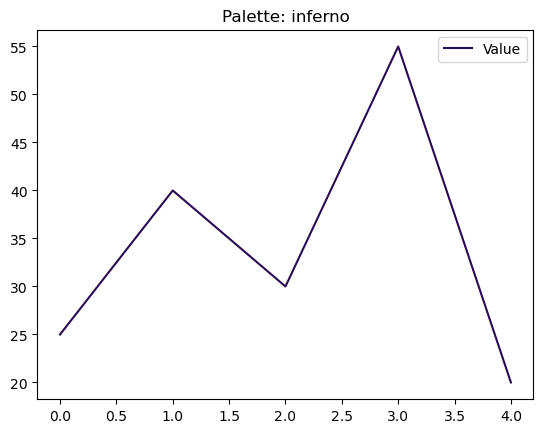

<Figure size 800x400 with 0 Axes>

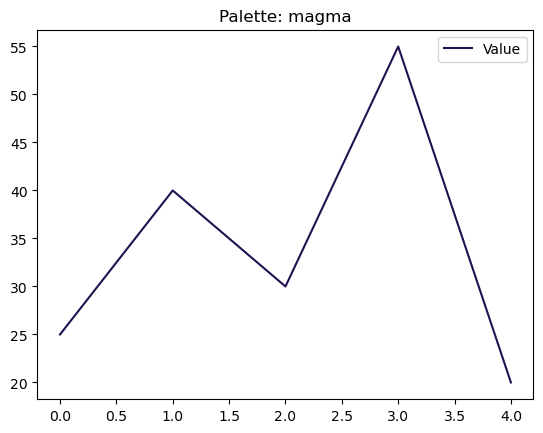

<Figure size 800x400 with 0 Axes>

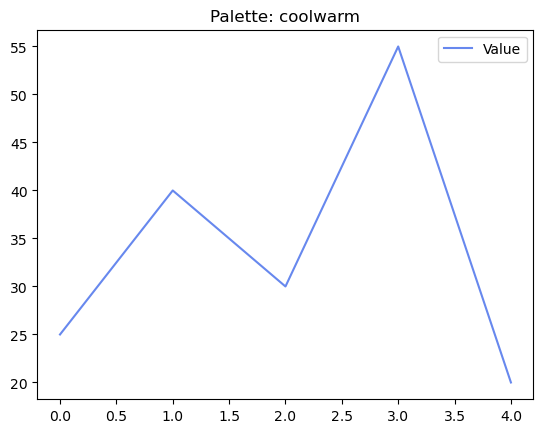

<Figure size 800x400 with 0 Axes>

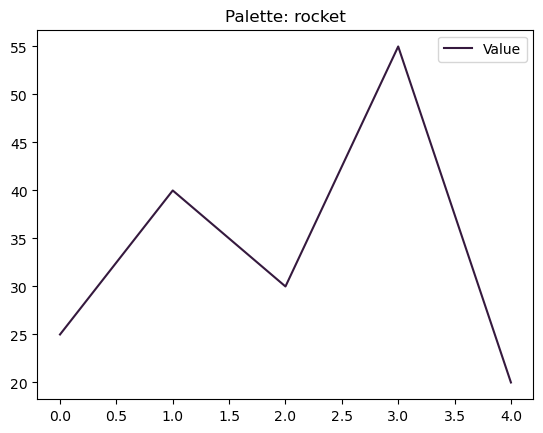

<Figure size 800x400 with 0 Axes>

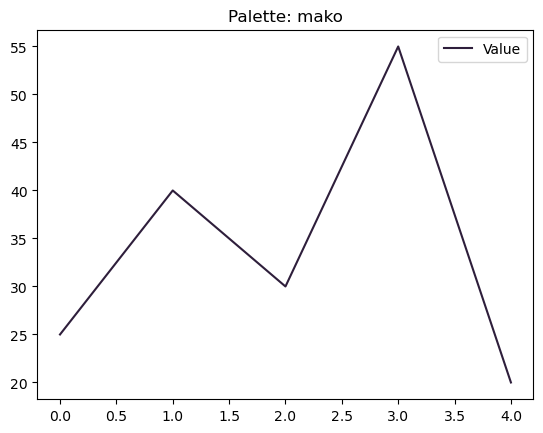

<Figure size 800x400 with 0 Axes>

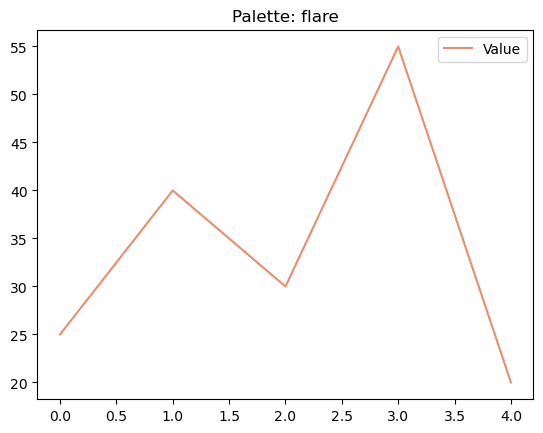

In [59]:
# Color palettes
palettes = ['viridis', 'plasma', 'inferno', 'magma', 'coolwarm', 'rocket', 'mako', 'flare']

for palette in palettes:
    plt.figure(figsize=(8, 4))
    sns.set_palette(palette)
    df.plot()
    plt.title(f'Palette: {palette}')
    plt.show()

# Custom palette
custom_palette = sns.color_palette("husl", 8)
sns.set_palette(custom_palette)

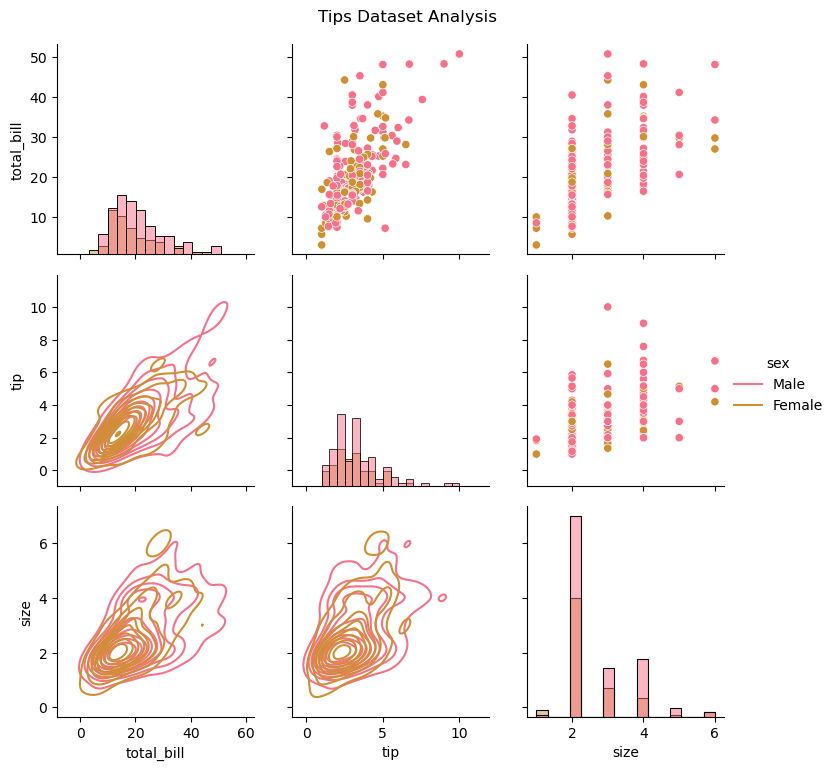

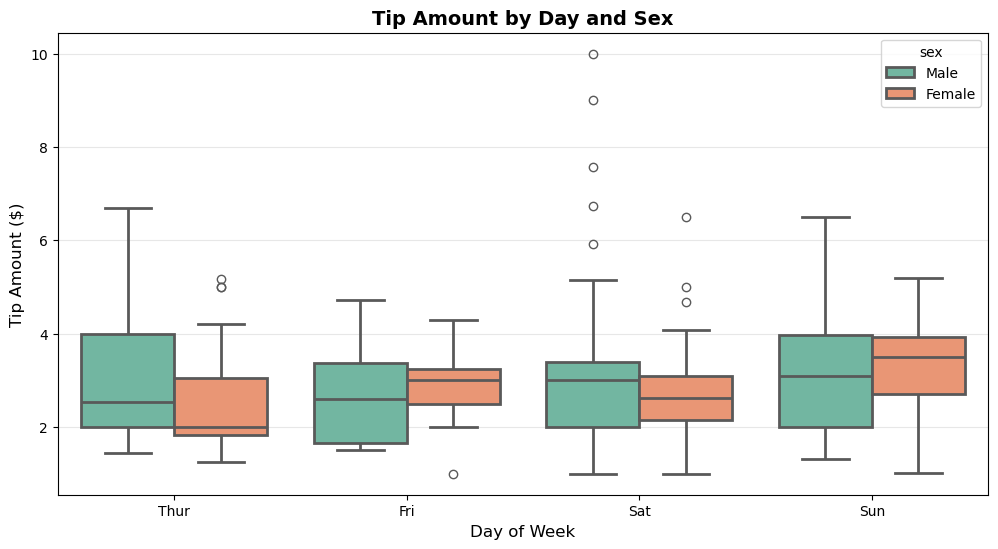

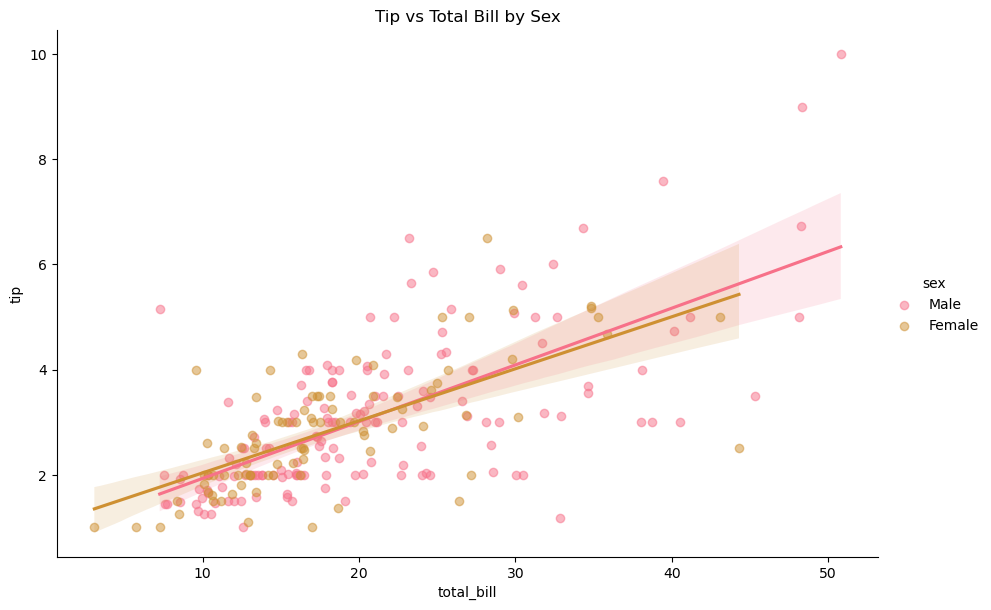

In [60]:
# Complete example: analyzing and visualizing the tips dataset
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load data
tips = sns.load_dataset('tips')

# 1. Explore relationships
g = sns.PairGrid(tips, hue='sex')
g.map_upper(sns.scatterplot)
g.map_lower(sns.kdeplot)
g.map_diag(sns.histplot)
g.add_legend()
plt.suptitle('Tips Dataset Analysis', y=1.02)
plt.show()

# 2. Box plot with custom colors
plt.figure(figsize=(12, 6))
sns.boxplot(x='day', y='tip', hue='sex', data=tips, 
            palette='Set2', linewidth=2)
plt.title('Tip Amount by Day and Sex', fontsize=14, fontweight='bold')
plt.xlabel('Day of Week', fontsize=12)
plt.ylabel('Tip Amount ($)', fontsize=12)
plt.grid(True, axis='y', alpha=0.3)
plt.show()

# 3. Regression plot
sns.lmplot(x='total_bill', y='tip', hue='sex', data=tips, 
           height=6, aspect=1.5, scatter_kws={'alpha':0.5})
plt.title('Tip vs Total Bill by Sex')
plt.show()